In [ ]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import numpy as np

In [55]:
headers={'User-Agent':'Mozilla/5.0 (Windows NT 6.3; Win 64 ; x64) Apple WeKit /537.36(KHTML , like Gecko) Chrome/80.0.3987.162 Safari/537.36'} 
url = "https://www.ambitionbox.com/list-of-companies?page=1"
webpage = requests.get(url, headers=headers).text

<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <link href="/assets/next/manifest.json" rel="manifest"/>
  <style>
   @media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}
  </style>
  <script>
   window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()
  </script>
  <script>
   window.Prism=window.Prism||{},window.Prism.manual=!0
  </script>
  <title>
   Top Companies in India | AmbitionBox
  </title>
  <meta content="2026 AmbitionBox" data-n-head="ssr" name="copyright"/>
  <meta content="1 day" data-n-head="ssr" name="revisit-after"/>
  <meta content="AmbitionBox" data-n-head="ssr" name="ap
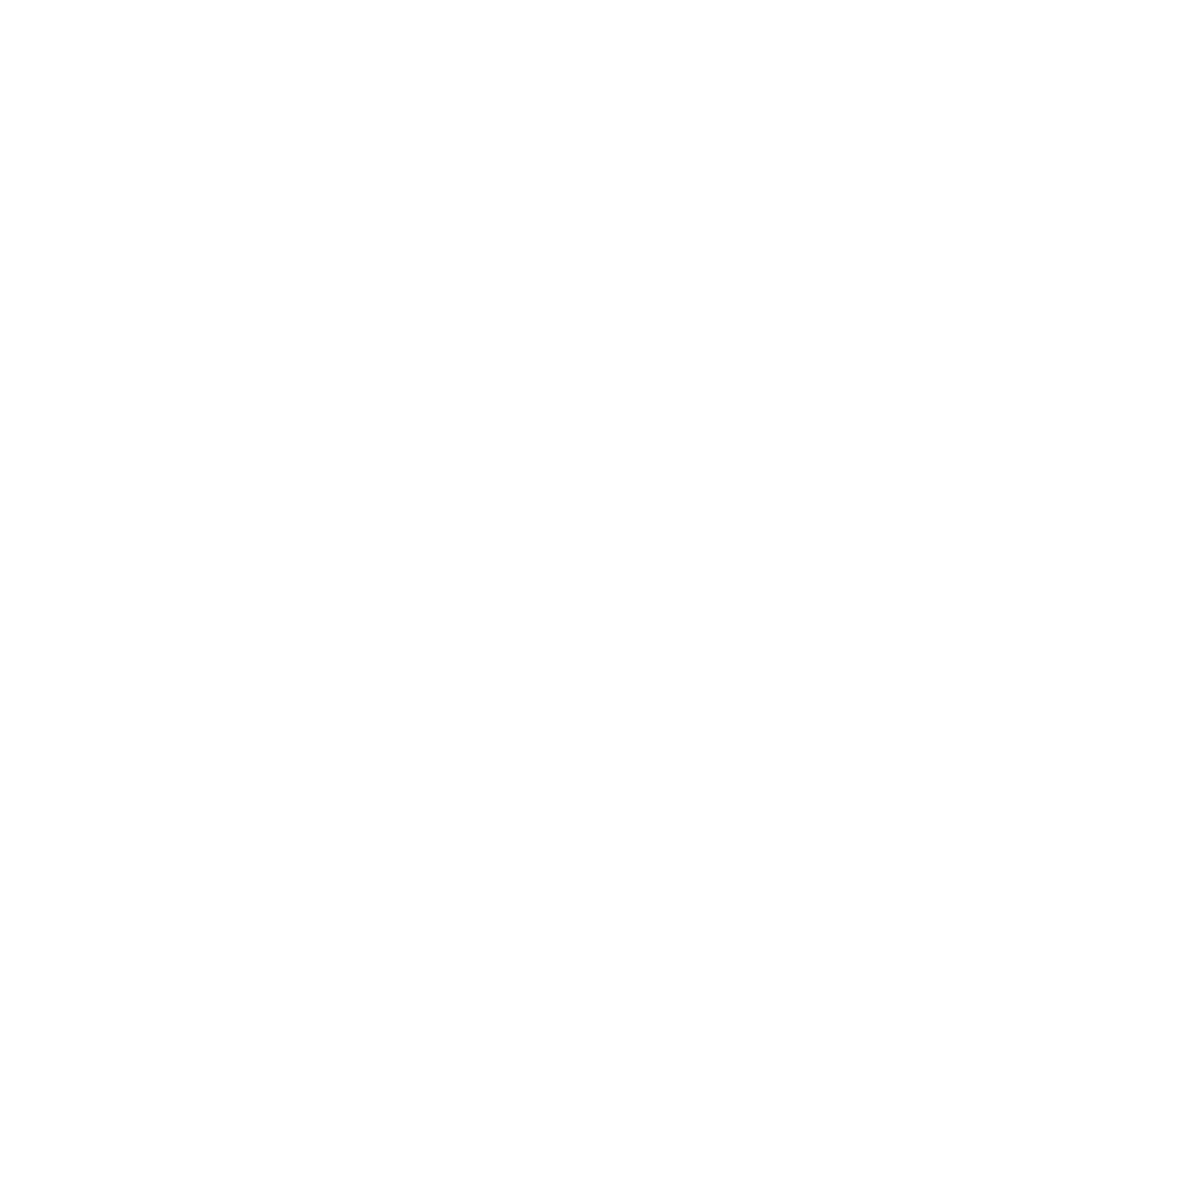

In [12]:
soup=BeautifulSoup(webpage)
print(soup.prettify())

In [16]:
soup.find_all("h1")[0].text.strip()

'Top Companies in\n\t\t\t\t \n\t\t\t\t\tINDIA'

In [18]:
for i in soup.find_all("h2"):
    print(i.text.strip())

Companies in India
TCS
Accenture
Wipro
Cognizant
Capgemini
HDFC Bank
Infosys
HCLTech
ICICI Bank
Tech Mahindra
Genpact
TP
Axis Bank
Jio
Concentrix Corporation
Amazon
Reliance Retail
iEnergizer
LTM Limited
HDB Financial Services
Popular Collections by Industries
Popular Collections by Cities
Popular Collections by Roles


In [41]:
soup.find_all("div", class_ = "rating_text")[0].text

'\n\t\t\t3.2'

In [26]:
soup.find_all("div", class_ = "companyCardWrapper")

[<div class="companyCardWrapper" itemprop="itemListElement" itemscope="itemscope" itemtype="http://schema.org/ListItem"><meta content="1" itemprop="position"/> <meta content="TCS" itemprop="name"/> <meta content="Tata Consultancy Services" itemprop="alternateName"/> <meta content="https://www.ambitionbox.com/overview/tcs-overview" itemprop="url"/> <meta content="https://static.ambitionbox.com/alpha/company/photos/logos/tcs-d-6a2a531408440-d-6a2a5419543b5.jpg" itemprop="image"/> <div class="companyCardWrapper__primaryInformation"><div class="companyCardWrapper__companyLogo"><img alt="Tata Consultancy Services logo" height="50" loading="lazy" onerror="this.onerror=null;this.src='https://static.ambitionbox.com/static/icons/company-placeholder.svg'" src="https://static.ambitionbox.com/assets/v2/images/rs:fit:200:200:false:false/aHR0cHM6Ly9tZWRpYS5uYXVrcmkuY29tL21lZGlhL2FiY29tcGxvZ28vdGNzLW9yaWdpbmFsLmpwZw.webp" width="50"/></div> <div class="companyCardWrapper__metaInformation"><div class=

In [51]:
names = []
ratings=[]
reviews=[]
ctype = []

for i in soup.find_all("div", class_ = "companyCardWrapper"):
    names.append(i.find("h2").text.strip())
    ratings.append(i.find("div", class_ ="rating_text").text.strip())
    reviews.append(i.find("span", class_="companyCardWrapper__companyRatingCount").text.strip())
    ctype.append(i.find("span", class_ = "companyCardWrapper__interLinking").text.strip().split("|")[0])

In [54]:
len(names)

20

In [56]:
final_df = pd.DataFrame()
for i in range(1001):
    requests.get("https://www.ambitionbox.com/list-of-companies?page={}".format(i), headers=headers)
    soup = BeautifulSoup(webpage)
    company = soup.find_all("div", class_ = "companyCardWrapper")

    names = []
    ratings=[]
    reviews=[]
    ctype = []

    for i in company:
        try:
            names.append(i.find("h2").text.strip())
        except:
            names.append(np.na)

        try:
            ratings.append(i.find("div", class_ ="rating_text").text.strip())
        except:
            ratings.append(np.na)

        try:
            reviews.append(i.find("span", class_="companyCardWrapper__companyRatingCount").text.strip())
        except:
            reviews.append(np.na)

        try:
            ctype.append(i.find("span", class_ = "companyCardWrapper__interLinking").text.strip().split("|")[0])
        except:
            ctype.append(np.na)
        

    temp_df = pd.DataFrame({
        "Name": names,
        "Rating": ratings,
        "Reviews": reviews,
        "Type": ctype
    })

    final_df = pd.concat([final_df, temp_df], ignore_index=True)

final_df.head()

,Name,Rating,Reviews,Type
0,TCS,3.2,(1.2L),IT Services & Consulting
1,Accenture,3.7,(77.5k),IT Services & Consulting
2,Wipro,3.6,(68.2k),IT Services & Consulting
3,Cognizant,3.7,(64.4k),IT Services & Consulting
4,Capgemini,3.6,(56.5k),IT Services & Consulting


In [59]:
final_df.head(25)

,Name,Rating,Reviews,Type
0,TCS,3.2,(1.2L),IT Services & Consulting
1,Accenture,3.7,(77.5k),IT Services & Consulting
2,Wipro,3.6,(68.2k),IT Services & Consulting
3,Cognizant,3.7,(64.4k),IT Services & Consulting
4,Capgemini,3.6,(56.5k),IT Services & Consulting
5,HDFC Bank,3.8,(55.6k),Banking
6,Infosys,3.5,(51.4k),IT Services & Consulting
7,HCLTech,3.4,(48.5k),IT Services & Consulting
8,ICICI Bank,3.9,(47.7k),Banking
9,Tech Mahindra,3.3,(45.5k),IT Services & Consulting


In [60]:
final_df.shape

(20020, 4)